# Access BICEP
    * Original Data Source: https://data.ceda.ac.uk/neodc/bicep/data
    * Reference:  https://opensciencedata.esa.int/projects/biological-pump-and-carbon-exchange-processes/collection
    * OSC entry: https://opensciencedata.esa.int/projects/biological-pump-and-carbon-exchange-processes/collection , https://opensciencedata.esa.int/products/bicep-database/collection.json
    * License: Open Data License (UK Gov)

In [1]:
import xarray as xr

In [2]:
zarr_href1 = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/bicep_marine_primary_productivity.zarr/'
zarr_href2 = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/bicep_oceanic_export_production.zarr/'
zarr_href3 = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/particulate_organic_carbon_geo.zarr'
zarr_href4 = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/phytoplankton_carbon.zarr/'

zarr_href1 = '/run/media/krasen/Storage/ocean/processed/bicep/bicep_marine_primary_productivity.zarr/'
zarr_href2 = '/run/media/krasen/Storage/ocean/processed/bicep/bicep_oceanic_export_production.zarr/'
zarr_href3 = '/run/media/krasen/Storage/ocean/processed/bicep/particulate_organic_carbon_geo.zarr'
zarr_href4 = '/run/media/krasen/Storage/ocean/processed/bicep/phytoplankton_carbon.zarr/'

In [20]:
ds = xr.open_zarr(zarr_href3)
ds

<xarray.Dataset> Size: 209GB
Dimensions:   (time: 280, lat: 4320, lon: 8640)
Coordinates:
  * time      (time) datetime64[ns] 2kB 1997-09-04 1997-10-01 ... 2020-12-01
  * lat       (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon       (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    POC       (time, lat, lon) float32 42GB dask.array<chunksize=(12, 1080, 2160), meta=np.ndarray>
    POC_bias  (time, lat, lon) float32 42GB dask.array<chunksize=(12, 1080, 2160), meta=np.ndarray>
    POC_rmsd  (time, lat, lon) float32 42GB dask.array<chunksize=(12, 1080, 2160), meta=np.ndarray>
    Rrs_490   (time, lat, lon) float32 42GB dask.array<chunksize=(12, 1080, 2160), meta=np.ndarray>
    Rrs_560   (time, lat, lon) float32 42GB dask.array<chunksize=(12, 1080, 2160), meta=np.ndarray>
Attributes: (12/26)
    title:                           NCEO/BICEP: Monthly global Particulate O...
    insitution:                      Plymouth Marine Laboratory (PML)
    project:                         European Space Agency (ESA): Biological ...
    contact(s):                      Shubha Sathyendranath (ssat@pml.ac.uk); ...
    processing_level:                Level-3
    product_version:                 5.0
    ...                              ...
    geospatial_vertical_max:         0.0
    geospatial_vertical_min:         0.0
    keywords:                        Particulate Organic Carbon, Ocean-Colour...
    summary:                         Monthly global Particulate Organic Carbo...
    history_data_source:             Rrs_490 and Rrs_560 were obtained from O...
    reference(s):                    please see https://bicep-project.org/Del...

##  marine primary productivity

In [ ]:
ds = xr.open_zarr(zarr_href1)
ds

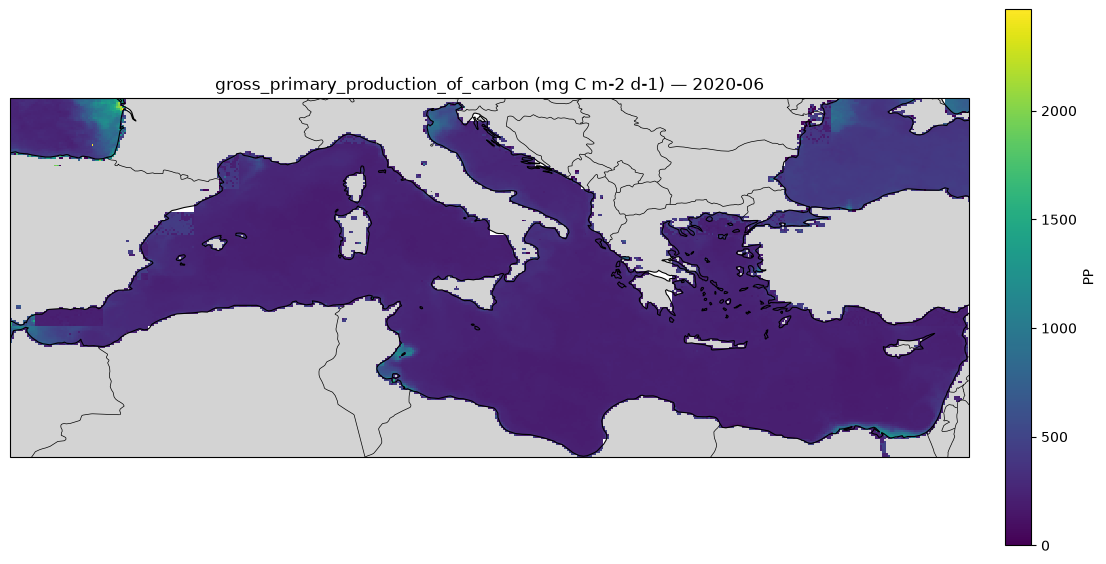

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Choose date
date = "2020-06"

# Select FSLE for that date
pp = ds["pp"].sel(time=np.datetime64(date), lon=slice(-6.062, 36.06), lat=slice(30.27, 45.98), drop=True)


# 2-D coordinates
lon = pp["lon"]
lat = pp["lat"]

# Create map
fig = plt.figure(figsize=(12, 7))

ax = plt.axes(projection=ccrs.PlateCarree())

# Plot FSLE
pcm = ax.pcolormesh(
    lon,
    lat,
    pp,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="viridis"
)

# Basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)



# Colourbar
cbar = plt.colorbar(
    pcm,
    ax=ax,
    orientation="vertical",
    pad=0.03,
    shrink=0.8
)
cbar.set_label("PP")

ax.set_title(f"gross_primary_production_of_carbon (mg C m-2 d-1) — {date}")

plt.tight_layout()
plt.show()

# Export Productivity

In [ ]:
ds = xr.open_zarr(zarr_href2)
ds

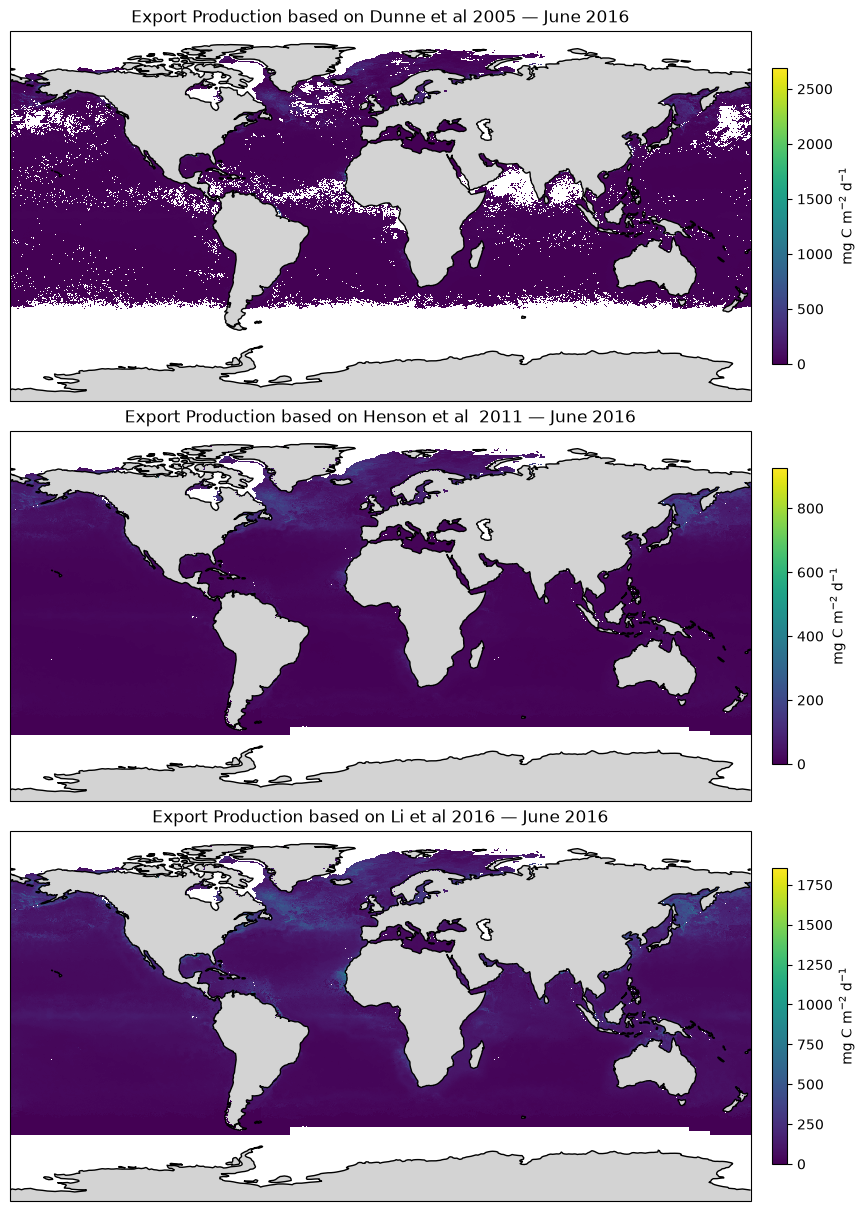

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select June 2016
# Your timestamps appear to be monthly, e.g. 2016-06-16
ds_june = ds.sel(time="2020-06").squeeze("time")

variables = ["EP_Dunne", "EP_Henson", "EP_Li"]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 12),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

for ax, var in zip(axes, variables):

    da = ds_june[var]

    im = ax.pcolormesh(
        ds_june.lon,
        ds_june.lat,
        da,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="viridis"
    )

    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.set_global()


    ax.set_title(
        f"{da.attrs.get('description', var)} — June 2016",
        fontsize=12
    )

    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="vertical",
        pad=0.02,
        shrink=0.8
    )
    cbar.set_label("mg C m$^{-2}$ d$^{-1}$")

plt.show()

# particulate_organic_carbon_geo

In [21]:
ds = xr.open_zarr(zarr_href3)
ds

<xarray.Dataset> Size: 209GB
Dimensions:   (time: 280, lat: 4320, lon: 8640)
Coordinates:
  * time      (time) datetime64[ns] 2kB 1997-09-04 1997-10-01 ... 2020-12-01
  * lat       (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon       (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    POC       (time, lat, lon) float32 42GB dask.array<chunksize=(12, 1080, 2160), meta=np.ndarray>
    POC_bias  (time, lat, lon) float32 42GB dask.array<chunksize=(12, 1080, 2160), meta=np.ndarray>
    POC_rmsd  (time, lat, lon) float32 42GB dask.array<chunksize=(12, 1080, 2160), meta=np.ndarray>
    Rrs_490   (time, lat, lon) float32 42GB dask.array<chunksize=(12, 1080, 2160), meta=np.ndarray>
    Rrs_560   (time, lat, lon) float32 42GB dask.array<chunksize=(12, 1080, 2160), meta=np.ndarray>
Attributes: (12/26)
    title:                           NCEO/BICEP: Monthly global Particulate O...
    insitution:                      Plymouth Marine Laboratory (PML)
    project:                         European Space Agency (ESA): Biological ...
    contact(s):                      Shubha Sathyendranath (ssat@pml.ac.uk); ...
    processing_level:                Level-3
    product_version:                 5.0
    ...                              ...
    geospatial_vertical_max:         0.0
    geospatial_vertical_min:         0.0
    keywords:                        Particulate Organic Carbon, Ocean-Colour...
    summary:                         Monthly global Particulate Organic Carbo...
    history_data_source:             Rrs_490 and Rrs_560 were obtained from O...
    reference(s):                    please see https://bicep-project.org/Del...

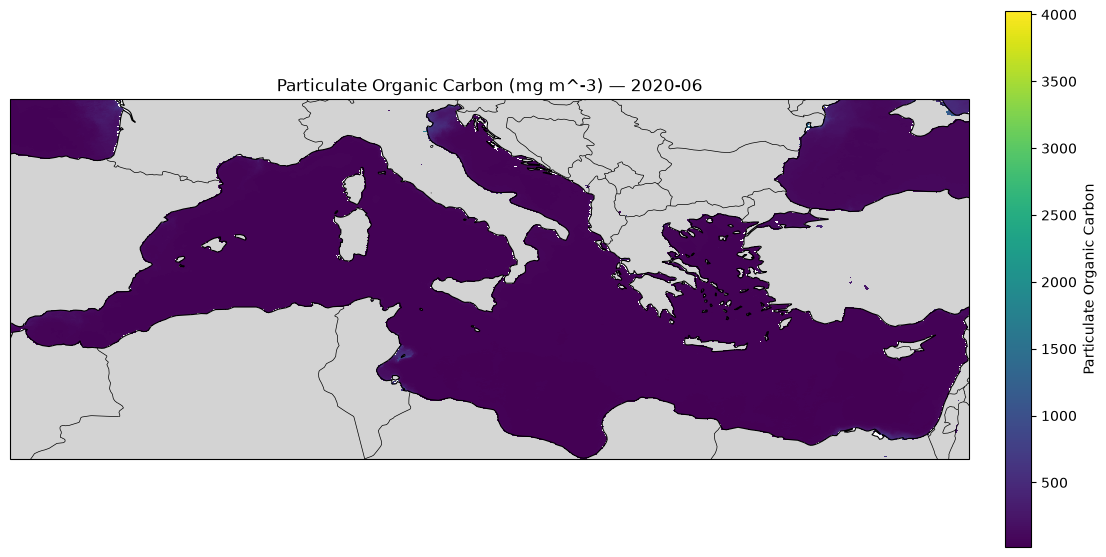

In [25]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Choose date
date = "2020-06"

# Select FSLE for that date
pp = ds["POC"].sel(time=np.datetime64(date), lon=slice(-6.062, 36.06), lat=slice(45.98, 30.27,), drop=True)


# 2-D coordinates
lon = pp["lon"]
lat = pp["lat"]

# Create map
fig = plt.figure(figsize=(12, 7))

ax = plt.axes(projection=ccrs.PlateCarree())

# Plot FSLE
pcm = ax.pcolormesh(
    lon,
    lat,
    pp,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="viridis"
)

# Basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)



# Colourbar
cbar = plt.colorbar(
    pcm,
    ax=ax,
    orientation="vertical",
    pad=0.03,
    shrink=0.8
)
cbar.set_label("Particulate Organic Carbon")

ax.set_title(f"Particulate Organic Carbon (mg m^-3) — {date}")

plt.tight_layout()
plt.show()

### phytoplankton_carbon

In [27]:
ds = xr.open_zarr(zarr_href4)
ds

<xarray.Dataset> Size: 165GB
Dimensions:               (time: 276, lat: 2160, lon: 4320)
Coordinates:
  * time                  (time) datetime64[ns] 2kB 1998-01-01 ... 2020-12-01
  * lat                   (lat) float32 9kB -89.96 -89.88 -89.79 ... 89.88 89.96
  * lon                   (lon) float32 17kB -180.0 -179.9 ... 179.9 180.0
Data variables:
    C_microphyto          (time, lat, lon) float64 21GB dask.array<chunksize=(8, 1080, 2160), meta=np.ndarray>
    C_nanophyto           (time, lat, lon) float64 21GB dask.array<chunksize=(8, 1080, 2160), meta=np.ndarray>
    C_phyto               (time, lat, lon) float64 21GB dask.array<chunksize=(8, 1080, 2160), meta=np.ndarray>
    C_picophyto           (time, lat, lon) float64 21GB dask.array<chunksize=(8, 1080, 2160), meta=np.ndarray>
    chl_a                 (time, lat, lon) float64 21GB dask.array<chunksize=(8, 1080, 2160), meta=np.ndarray>
    latitude              (lat) float32 9kB dask.array<chunksize=(1080,), meta=np.ndarray>
    longitude             (lon) float32 17kB dask.array<chunksize=(2160,), meta=np.ndarray>
    mean_spectral_i_star  (time, lat, lon) float64 21GB dask.array<chunksize=(8, 1080, 2160), meta=np.ndarray>
    mld                   (time, lat, lon) float64 21GB dask.array<chunksize=(8, 1080, 2160), meta=np.ndarray>
    par                   (time, lat, lon) float64 21GB dask.array<chunksize=(8, 1080, 2160), meta=np.ndarray>
Attributes:
    institution:  Plymouth Marine Laboratory (PML)
    Convention:   CF-1.8
    contact:      Shubha Sathyendranath (ssat@pml.ac.uk)
    keywords:     Phytoplankton, Carbon, Ocean-Colour Remote Sensing
    references:   Sathyendranath S.; Platt T.; Kovac Z.; Dingle J.; Jackson T...
    title:        BICEP / NCEO: Monthly global Phytoplankton Carbon, between ...
    summary:      A spectrally-resolved photoacclimation model was unified wi...

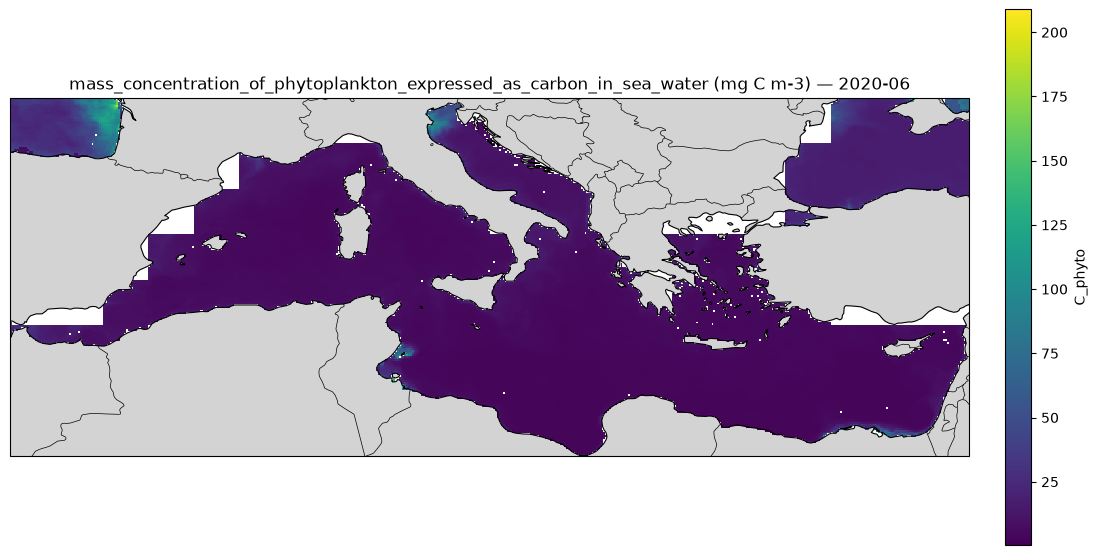

In [29]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Choose date
date = "2020-06"

# Select FSLE for that date
pp = ds["C_phyto"].sel(time=np.datetime64(date), lon=slice(-6.062, 36.06), lat=slice(30.27,45.98), drop=True)


# 2-D coordinates
lon = pp["lon"]
lat = pp["lat"]

# Create map
fig = plt.figure(figsize=(12, 7))

ax = plt.axes(projection=ccrs.PlateCarree())

# Plot FSLE
pcm = ax.pcolormesh(
    lon,
    lat,
    pp,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="viridis"
)

# Basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)



# Colourbar
cbar = plt.colorbar(
    pcm,
    ax=ax,
    orientation="vertical",
    pad=0.03,
    shrink=0.8
)
cbar.set_label("C_phyto")

ax.set_title(f"mass_concentration_of_phytoplankton_expressed_as_carbon_in_sea_water (mg C m-3) — {date}")

plt.tight_layout()
plt.show()